#**Deep BSDE Solver for High-Dimensional Black-Scholes**

**Garnett Bertrand Pardomuan Hutahaean**


## Imports and Setup

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import time

# Setting random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Checking for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


##The Market Environment (SDEs and Exact Benchmarks)

In [9]:
class HighDimBlackScholes:
    def __init__(self, dim=100, total_time=1.0, num_time_intervals=20):
        self.d = dim  # Number of dimensions (assets)
        self.T = total_time
        self.N = num_time_intervals
        self.dt = self.T / self.N

        # Market parameters (can be calibrated to global indices)
        self.mu = 0.05  # Drift
        self.sigma = 0.2  # Volatility

        # Non-Linearity
        self.r_l = 0.04  # Lending rate
        self.r_b = 0.06  # Borrowing rate

        # Initial asset prices and strike
        self.X_0 = torch.ones(self.d).to(device) * 100.0
        self.strike = 100.0

    def generate_paths(self, batch_size):
        "Simulates the forward SDE (Geometric Brownian Motion)"
        dW = torch.randn(batch_size, self.N, self.d).to(device) * np.sqrt(self.dt)
        X = torch.zeros(batch_size, self.N + 1, self.d).to(device)
        X[:, 0, :] = self.X_0

        for t in range(self.N):
            X[:, t+1, :] = X[:, t, :] + self.mu * X[:, t, :] * self.dt + \
                           self.sigma * X[:, t, :] * dW[:, t, :]
        return X, dW

    def driver(self, t, X, Y, Z):
        """
        Non-linear generator f(t, X, Y, Z).
        If portfolio value > replicated assets, we lend at r_l.
        If we are short, we borrow at r_b.
        """
        hedge_value = torch.sum(Z / self.sigma, dim=1, keepdim=True)
        borrowed_amount = Y - hedge_value

        # Apply non-linear rate
        rate = torch.where(borrowed_amount > 0, self.r_b, self.r_l)
        return -rate * Y

    def terminal_condition(self, X_T):
        "Payoff function g(X_T) for a Geometric Basket Option"
        geometric_avg = torch.exp(torch.mean(torch.log(X_T), dim=1))
        return torch.relu(geometric_avg - self.strike)

    def analytical_pricing(self):
        "Exact closed-form solution for a Geometric Basket Option"
        sigma_hat = self.sigma / np.sqrt(self.d)
        q = 0.5 * self.sigma**2 * (1 - 1/self.d)

        S0 = self.X_0[0].item()

        d1 = (np.log(S0 / self.strike) + (self.r_l - q + 0.5 * sigma_hat**2) * self.T) / (sigma_hat * np.sqrt(self.T))
        d2 = d1 - sigma_hat * np.sqrt(self.T)

        exact_price = np.exp(-q * self.T) * S0 * norm.cdf(d1) - \
                      np.exp(-self.r_l * self.T) * self.strike * norm.cdf(d2)
        return exact_price

##Deep Learning Architecture (Sub-Networks per Time Step)

In [10]:
class SubNetwork(nn.Module):
    "Feed-forward neural network for a single time step to approximate Z_t"
    def __init__(self, dim):
        super(SubNetwork, self).__init__()
        hidden_dim = dim + 10
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim, momentum=0.1),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim, momentum=0.1),
            nn.ReLU(),
            nn.Linear(hidden_dim, dim)
        )

    def forward(self, x):
        return self.net(x)

class DeepBSDE(nn.Module):
    "Integrates the Forward paths and Backward networks"
    def __init__(self, config):
        super(DeepBSDE, self).__init__()
        self.config = config

        # Trainable parameters: Y_0 (Option Price) and Z_0 (Initial Deltas)
        self.Y_0 = nn.Parameter(torch.rand(1) * 10)
        self.Z_0 = nn.Parameter(torch.zeros(1, self.config.d))

        # List of neural networks, one for each time step
        self.sub_networks = nn.ModuleList([SubNetwork(self.config.d)
                                           for _ in range(self.config.N - 1)])

    def forward(self, X, dW):
        batch_size = X.shape[0]

        Y = self.Y_0.expand(batch_size, 1)
        Z = self.Z_0.expand(batch_size, self.config.d)

        # Forward simulate the Backward SDE using Euler-Maruyama
        for t in range(self.config.N):
            Y = Y - self.config.driver(t, X[:, t, :], Y, Z) * self.config.dt + \
                torch.sum(Z * dW[:, t, :], dim=1, keepdim=True)

            if t < self.config.N - 1:
                Z = self.sub_networks[t](X[:, t+1, :])

        return Y

##Training Execution

In [11]:
# Hyperparameters
BATCH_SIZE = 64
EPOCHS = 3000
LEARNING_RATE = 1e-2

# Initialize market and model
market = HighDimBlackScholes(dim=100)
model = DeepBSDE(market).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[1000, 2000], gamma=0.1)

# Get the true benchmark price
true_price = market.analytical_pricing()
print(f"Analytical True Price (Benchmark): {true_price:.4f}")

# Tracking metrics
loss_history = []
y0_history = []

print("\nStarting training...")
start_time = time.time()

for epoch in range(EPOCHS):
    optimizer.zero_grad()

    # Simulate forward paths
    X, dW = market.generate_paths(BATCH_SIZE)

    # Forward pass through Deep BSDE
    Y_terminal_pred = model(X, dW)

    # Calculate true terminal payoff based on state X_T
    Y_terminal_true = market.terminal_condition(X[:, -1, :]).unsqueeze(1)

    # Loss is the MSE between the replicated portfolio value and actual payoff
    loss = nn.MSELoss()(Y_terminal_pred, Y_terminal_true)

    loss.backward()
    optimizer.step()
    scheduler.step()

    loss_history.append(loss.item())
    y0_history.append(model.Y_0.item())

    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch+1:4d}/{EPOCHS} | Loss: {loss.item():.4f} | "
              f"Predicted Y_0: {model.Y_0.item():.4f} | Error: {abs(model.Y_0.item() - true_price):.4f}")

end_time = time.time()
print(f"Final Predicted Price: {model.Y_0.item():.4f}")
print(f"Exact Analytical Price: {true_price:.4f}")

Analytical True Price (Benchmark): 2.1192

Starting training...
Epoch  500/3000 | Loss: 6.4903 | Predicted Y_0: 4.9843 | Error: 2.8651
Epoch 1000/3000 | Loss: 0.4589 | Predicted Y_0: 3.3560 | Error: 1.2368
Epoch 1500/3000 | Loss: 0.3780 | Predicted Y_0: 3.2788 | Error: 1.1596
Epoch 2000/3000 | Loss: 0.3366 | Predicted Y_0: 3.1987 | Error: 1.0795
Epoch 2500/3000 | Loss: 0.2290 | Predicted Y_0: 3.1902 | Error: 1.0710
Epoch 3000/3000 | Loss: 0.2380 | Predicted Y_0: 3.1797 | Error: 1.0605

Training completed in 96.50 seconds.
Final Predicted Price: 3.1797
Exact Analytical Price: 2.1192


##Visualizing Convergence and Hedging Strategies

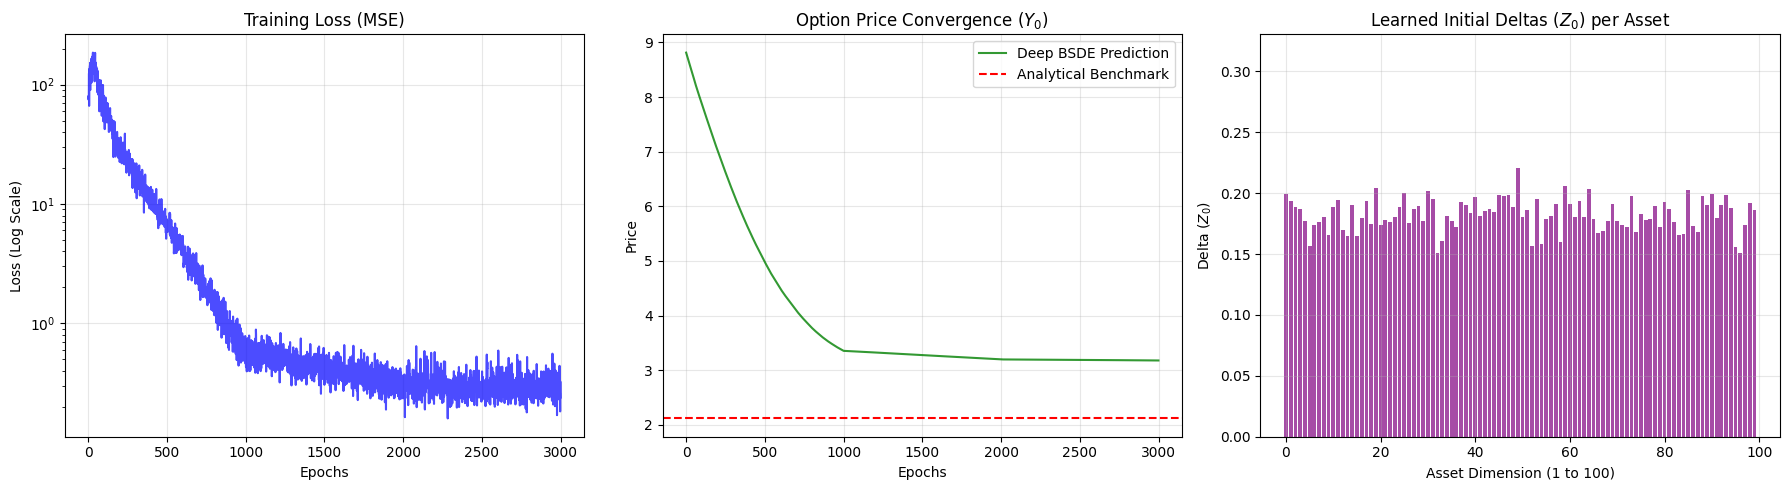

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. Plot Loss Decay
ax[0].plot(loss_history, color='blue', alpha=0.7)
ax[0].set_yscale('log')
ax[0].set_title('Training Loss (MSE)')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (Log Scale)')
ax[0].grid(True, alpha=0.3)

# 2. Plot Option Price Convergence against Benchmark
ax[1].plot(y0_history, color='green', alpha=0.8, label='Deep BSDE Prediction')
ax[1].axhline(y=true_price, color='red', linestyle='--', label='Analytical Benchmark')
ax[1].set_title('Option Price Convergence ($Y_0$)')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Price')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

# 3. Delta Analysis (Z_0)
learned_Z0 = model.Z_0.detach().cpu().numpy().flatten()

ax[2].bar(range(market.d), learned_Z0, color='purple', alpha=0.7)
ax[2].set_title('Learned Initial Deltas ($Z_0$) per Asset')
ax[2].set_xlabel('Asset Dimension (1 to 100)')
ax[2].set_ylabel('Delta ($Z_0$)')
ax[2].grid(True, alpha=0.3)
ax[2].set_ylim([0, max(learned_Z0) * 1.5])

plt.tight_layout()
plt.show()